<a href="https://colab.research.google.com/github/Shubhanshi-Shaurya/placement-predictor/blob/main/placement_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd


In [ ]:
df=pd.read_csv('/content/placement.csv')

In [ ]:
df

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0
...,...,...,...,...
95,95,4.3,200.0,0
96,96,4.4,42.0,0
97,97,6.7,182.0,1
98,98,6.3,103.0,1


In [ ]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [ ]:
df.shape

(100, 4)

In [ ]:
df=df.iloc[:,1:]

In [ ]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [ ]:
#STEPS
#0.PREPROCESS+EDA+FEATURE SELECTION
#1.EXTRACT INPUT AND OUTPUT COLS
#2.SCALE THE VALUES
#3.TRAIN TEST SPLIT
#4.TRAIN THE MODEL
#5.EVALUATE THE MODEL/MODEL SELECTION
#6.DEPLOY THE MODEL

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

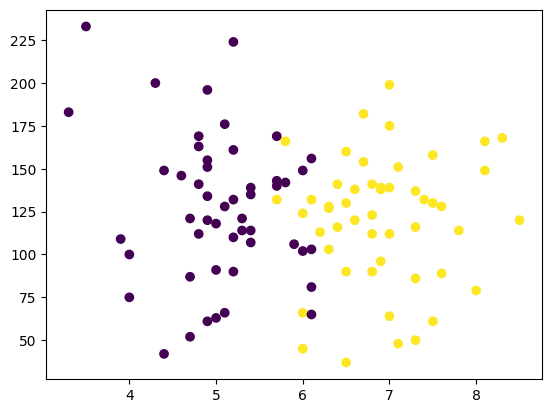

In [ ]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [ ]:
X=df.iloc[:,0:2]
y=df.iloc[:,-1]

In [ ]:
X

,Unnamed: 0,cgpa
0,0,6.8
1,1,5.9
2,2,5.3
3,3,7.4
4,4,5.8
...,...,...
95,95,4.3
96,96,4.4
97,97,6.7
98,98,6.3


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1)

In [ ]:
X_train


,Unnamed: 0,cgpa
37,37,8.1
22,22,4.9
23,23,4.7
14,14,6.1
46,46,5.3
...,...,...
33,33,6.0
39,39,4.6
99,99,6.2
31,31,3.9


In [ ]:
y_train

,placement
37,1
22,0
23,0
14,0
46,0
...,...
33,0
39,0
99,1
31,0


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)

In [ ]:
X_train

array([[-0.38019717,  1.90685446],
       [-0.89500778, -0.97443665],
       [-0.86068707, -1.15451734],
       [-1.16957343,  0.10604752],
       [-0.0713108 , -0.61427526],
       [ 0.99263112,  1.18653169],
       [-0.9979699 , -0.7043156 ],
       [ 1.26719678, -0.16407352],
       [-1.34117697, -0.79435595],
       [-0.92932848,  1.00645099],
       [-0.20859363,  1.45665273],
       [-0.65476282,  0.91641064],
       [ 0.47782051,  0.01600717],
       [ 0.44349981,  1.18653169],
       [ 1.19855536,  1.36661238],
       [ 0.54646193,  0.91641064],
       [-1.0322906 , -1.78479977],
       [ 1.06127253,  0.46620891],
       [ 0.78670688,  0.10604752],
       [ 0.889669  ,  0.6462896 ],
       [-0.68908353, -0.7043156 ],
       [-1.10093202, -0.7043156 ],
       [ 1.30151748, -0.79435595],
       [-1.65006333,  0.73632995],
       [-1.40981838, -0.8843963 ],
       [ 1.67904526,  0.6462896 ],
       [ 1.16423466,  0.46620891],
       [-1.54710121,  1.27657203],
       [ 1.50744173,

In [ ]:
X_test=scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
clf=LogisticRegression()

In [ ]:
#model training
clf.fit(X_train,y_train)

LogisticRegression()

In [ ]:
y_pred=clf.predict(X_test)

In [ ]:
y_test

,placement
40,0
68,0
58,1
59,0
30,1
91,1
84,0
27,1
76,0
90,1


In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9

/tmp/ipykernel_6282/2520758695.py:2: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  plot_decision_regions(X_train, y_train.ravel(), clf=clf, legend=2)


<Axes: >

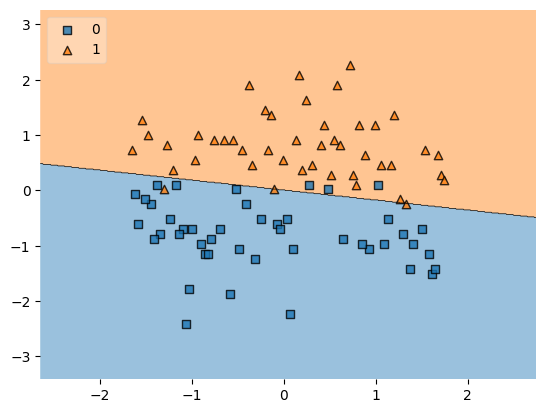

In [ ]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X_train, y_train.ravel(), clf=clf, legend=2)

###Importing model as pkl file

In [ ]:
import pickle

In [ ]:
pickle.dump(clf,open('model.pkl','wb'))